# Experimentação Adaptativa v2 —
### Datathon 7-MLET · Etapas 2 e 3

---

**O que mudou em relação à v1:**

| Ponto | v1 (anterior) | v2 (este notebook) |
|-------|---------------|---------------------|
| Braços | 5 produtos financeiros inventados | Variações de canal/CTA do MESMO produto (term deposit) |
| Uso do `y` | Boost genérico pequeno (+0.03) | **Âncora direta**: braço de referência usa o `y` real por segmento |
| Delayed reward | Sorteado na hora se é "pending" | **Fila real**: evento amadurece em round futuro, update só acontece então |
| RAG / política | Não existia | Documentos sintéticos de suitability + golden set com casos de "furar suitability" |

**Por que essa mudança importa:**

Resolve a pergunta "se a base só tem 1 produto, qual o ganho do bandit?" de forma honesta:
o braço de referência usa o `y` real agregado por segmento — não é mais um chute solto.
Os demais braços (variações de canal) derivam dessa âncora com multiplicadores documentados.

---
**Pré-requisito:** `bank.csv` (separador `;`) na mesma pasta.

## Célula 1 — Setup

In [1]:
import json
import heapq
import random
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

SEED = 42
rng  = np.random.default_rng(SEED)
random.seed(SEED)

for p in ["data/synthetic_enrichment", "data/golden_set", "data/policies", "reports"]:
    Path(p).mkdir(parents=True, exist_ok=True)

print("✓ Setup concluído.")

C:\Users\Pedro\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✓ Setup concluído.


## Célula 2 — Carregar o dataset e calcular o `y` por segmento

Esse é o ponto central da mudança: em vez de usar `y` como boost genérico,
calculamos a **taxa de conversão real por segmento** — esse valor vai ser
a âncora do braço de referência.

In [2]:
CAMINHO_CSV = "bank-additional-full.csv"
SEPARADOR   = ";"

df = pd.read_csv(CAMINHO_CSV, sep=SEPARADOR)

VAZAMENTO = ["duration","pdays","previous","poutcome","emp.var.rate",
             "cons.price.idx","cons.conf.idx","euribor3m","nr.employed",
             "contact","month","day_of_week"]
df.drop(columns=[c for c in VAZAMENTO if c in df.columns], inplace=True)

CONTEXTO = ["age","job","marital","education","default","housing","loan"]
CONTEXTO = [c for c in CONTEXTO if c in df.columns]

if "y" in df.columns:
    df["y"] = df["y"].map({"yes":1,"no":0}).fillna(0).astype(int)

df = df[CONTEXTO + (["y"] if "y" in df.columns else [])].dropna().reset_index(drop=True)
print(f"Dataset: {df.shape[0]:,} clientes")


def segmento(row) -> str:
    """
    Agrupa cliente em segmento. É a chave de calibração: cada segmento
    terá sua própria taxa de conversão real extraída do Kaggle.
    """
    age = int(row.get("age", 0))
    job = str(row.get("job", "unknown"))
    age_grp = "senior" if age >= 55 else ("young" if age <= 30 else "mid")
    return f"{job}__{age_grp}"


df["segmento"] = df.apply(segmento, axis=1)

# ── ÂNCORA: taxa de conversão real por segmento ──────────────────────
Y_POR_SEGMENTO = df.groupby("segmento")["y"].mean().to_dict()
Y_GLOBAL       = df["y"].mean()
N_POR_SEGMENTO = df.groupby("segmento").size().to_dict()

# Segmentos com poucos dados usam o y_global (shrinkage simples)
MIN_AMOSTRAS = 15
for seg, n in N_POR_SEGMENTO.items():
    if n < MIN_AMOSTRAS:
        # Média ponderada entre segmento e global — evita ruído de poucos dados
        peso = n / MIN_AMOSTRAS
        Y_POR_SEGMENTO[seg] = peso * Y_POR_SEGMENTO[seg] + (1 - peso) * Y_GLOBAL

print(f"\nY global (taxa de conversão média): {Y_GLOBAL:.1%}")
print(f"Segmentos distintos encontrados: {len(Y_POR_SEGMENTO)}")
print(f"\nAmostra de taxas por segmento:")
for seg, taxa in sorted(Y_POR_SEGMENTO.items(), key=lambda x: -x[1])[:8]:
    n = N_POR_SEGMENTO.get(seg, 0)
    print(f"  {seg:<30} {taxa:.1%}  (n={n})")

Dataset: 41,188 clientes

Y global (taxa de conversão média): 11.3%
Segmentos distintos encontrados: 35

Amostra de taxas por segmento:
  student__young                 33.2%  (n=736)
  retired__senior                28.8%  (n=1437)
  unknown__young                 27.3%  (n=33)
  unemployed__senior             25.6%  (n=78)
  student__mid                   22.3%  (n=139)
  unemployed__young              20.7%  (n=169)
  housemaid__senior              20.6%  (n=214)
  unknown__senior                20.3%  (n=79)


## Célula 3 — Catálogo de braços: variações de canal/CTA

**Decisão de design seguindo a orientação do coordenador:**

Os braços NÃO são produtos diferentes. São variações de **como** a mesma
oferta (term deposit) é apresentada: canal de contato, tipo de CTA.

Cada braço tem um **multiplicador** sobre a probabilidade-âncora do segmento.
Isso é uma hipótese de domínio — precisa estar documentada — mas é uma hipótese
muito mais simples e defensável que inventar 5 produtos do zero.

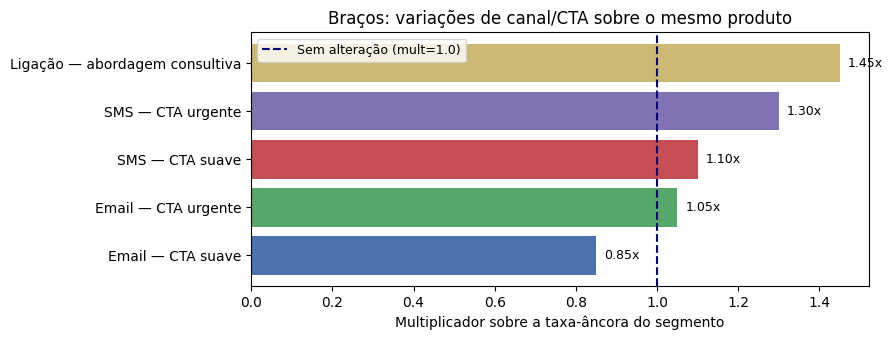

✓ Catálogo salvo: 5 braços
  Braço de referência (mais próximo do y real): ARM_EMAIL_SOFT


In [3]:
ARMS = [
    {
        "arm_id":     "ARM_EMAIL_SOFT",
        "name":       "Email — CTA suave",
        "canal":      "email",
        "cta":        "soft",
        # Hipótese: email com CTA suave tem menor urgência percebida → reduz conversão
        "mult":       0.85,
        "custo_rel":  0.2,   # custo relativo de operação (email é barato)
    },
    {
        "arm_id":     "ARM_EMAIL_URGENTE",
        "name":       "Email — CTA urgente",
        "canal":      "email",
        "cta":        "urgente",
        # Hipótese: urgência no email aumenta levemente a conversão
        "mult":       1.05,
        "custo_rel":  0.2,
    },
    {
        "arm_id":     "ARM_SMS_SOFT",
        "name":       "SMS — CTA suave",
        "canal":      "sms",
        "cta":        "soft",
        # Hipótese: SMS tem taxa de abertura maior que email
        "mult":       1.10,
        "custo_rel":  0.5,
    },
    {
        "arm_id":     "ARM_SMS_URGENTE",
        "name":       "SMS — CTA urgente",
        "canal":      "sms",
        "cta":        "urgente",
        # Hipótese: SMS + urgência tem maior taxa de ação imediata
        "mult":       1.30,
        "custo_rel":  0.5,
    },
    {
        "arm_id":     "ARM_CALL_CONSULTIVO",
        "name":       "Ligação — abordagem consultiva",
        "canal":      "call",
        "cta":        "consultivo",
        # Hipótese: contato humano tem maior taxa de conversão, mas custa mais
        "mult":       1.45,
        "custo_rel":  1.0,
    },
]

ARM_IDS = [a["arm_id"] for a in ARMS]
ARM_MAP = {a["arm_id"]: a for a in ARMS}

# Braço de referência — é o que está mais próximo do dado real (sem perturbação forte)
BRACO_REFERENCIA = "ARM_EMAIL_SOFT"

with open("data/synthetic_enrichment/offer_catalog.json", "w", encoding="utf-8") as f:
    json.dump({
        "produto_base": "term_deposit (Bank Marketing)",
        "braco_referencia": BRACO_REFERENCIA,
        "arms": ARMS,
    }, f, ensure_ascii=False, indent=2)

# Visualiza os multiplicadores
fig, ax = plt.subplots(figsize=(9, 3.5))
nomes = [a["name"] for a in ARMS]
mults = [a["mult"] for a in ARMS]
cores = ["#4C72B0","#55A868","#C44E52","#8172B2","#CCB974"]
bars = ax.barh(nomes, mults, color=cores)
ax.axvline(1.0, color="navy", linestyle="--", linewidth=1.5, label="Sem alteração (mult=1.0)")
ax.set_xlabel("Multiplicador sobre a taxa-âncora do segmento")
ax.set_title("Braços: variações de canal/CTA sobre o mesmo produto")
ax.legend(fontsize=9)
for bar, val in zip(bars, mults):
    ax.text(val+0.02, bar.get_y()+bar.get_height()/2, f"{val:.2f}x", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"✓ Catálogo salvo: {len(ARMS)} braços")
print(f"  Braço de referência (mais próximo do y real): {BRACO_REFERENCIA}")

## Célula 4 — Função de probabilidade: âncora + multiplicador

Esta é a função central da v2:

```
P(conversão | segmento, braço) = y_real_do_segmento × multiplicador_do_braço
```

O braço de referência (`ARM_EMAIL_SOFT`) é o mais próximo do dado real — seu
multiplicador é o que menos distorce. Os outros braços se afastam dessa
âncora de forma documentada.

In [4]:
def prob_conversao(seg: str, arm_id: str) -> float:
    """
    P(conversão) = taxa de conversão REAL do segmento (do Kaggle) × multiplicador do braço.

    Isso é diferente da v1: aqui o y real é o ponto de partida de TODOS os braços,
    não um boost genérico. A 'verdade' do simulador vem diretamente do dado observado.
    """
    y_base = Y_POR_SEGMENTO.get(seg, Y_GLOBAL)
    mult   = ARM_MAP[arm_id]["mult"]
    return float(np.clip(y_base * mult, 0.01, 0.95))


# ── Demonstração ──────────────────────────────────────────────────
print("Como a âncora funciona na prática:\n")
segs_exemplo = sorted(Y_POR_SEGMENTO.items(), key=lambda x: -x[1])[:3]

for seg, y_base in segs_exemplo:
    print(f"Segmento: {seg}  (y_real={y_base:.1%})")
    for arm_id in ARM_IDS:
        p = prob_conversao(seg, arm_id)
        bar = "█" * int(p * 50)
        print(f"  {arm_id:<22} {p:.1%}  {bar}")
    print()

Como a âncora funciona na prática:

Segmento: student__young  (y_real=33.2%)
  ARM_EMAIL_SOFT         28.2%  ██████████████
  ARM_EMAIL_URGENTE      34.8%  █████████████████
  ARM_SMS_SOFT           36.5%  ██████████████████
  ARM_SMS_URGENTE        43.1%  █████████████████████
  ARM_CALL_CONSULTIVO    48.1%  ████████████████████████

Segmento: retired__senior  (y_real=28.8%)
  ARM_EMAIL_SOFT         24.5%  ████████████
  ARM_EMAIL_URGENTE      30.3%  ███████████████
  ARM_SMS_SOFT           31.7%  ███████████████
  ARM_SMS_URGENTE        37.5%  ██████████████████
  ARM_CALL_CONSULTIVO    41.8%  ████████████████████

Segmento: unknown__young  (y_real=27.3%)
  ARM_EMAIL_SOFT         23.2%  ███████████
  ARM_EMAIL_URGENTE      28.6%  ██████████████
  ARM_SMS_SOFT           30.0%  ███████████████
  ARM_SMS_URGENTE        35.5%  █████████████████
  ARM_CALL_CONSULTIVO    39.5%  ███████████████████



## Célula 5 — Algoritmos: Baseline e Thompson Contextual

Igual à v1 na estrutura, mas agora operando sobre os braços de canal
e a probabilidade ancorada no y real.

In [5]:
class BaselineDeterministico:
    """Regra fixa — sempre o mesmo braço. Confirmado pelo coordenador como válido."""
    def __init__(self, arm_ids, fixed_arm=None):
        self.arm_ids   = arm_ids
        self.fixed_arm = fixed_arm or arm_ids[0]
        self.nome      = "Baseline fixo"

    def escolher(self, segmento_cliente=None):
        return self.fixed_arm

    def atualizar(self, arm_id, reward, segmento_cliente=None):
        pass


class ThompsonContextual:
    """Thompson Sampling com contador (alpha, beta) por segmento × braço."""
    def __init__(self, arm_ids, seed=42):
        self.arm_ids = arm_ids
        self.rng     = np.random.default_rng(seed)
        self.nome    = "Thompson Contextual"
        self.alpha   = {}
        self.beta    = {}

    def _chave(self, seg, arm_id):
        return f"{seg}__{arm_id}"

    def _garantir(self, seg):
        for a in self.arm_ids:
            k = self._chave(seg, a)
            if k not in self.alpha:
                self.alpha[k] = 1
                self.beta[k]  = 1

    def escolher(self, segmento_cliente):
        self._garantir(segmento_cliente)
        amostras = {
            a: self.rng.beta(self.alpha[self._chave(segmento_cliente,a)],
                             self.beta[ self._chave(segmento_cliente,a)])
            for a in self.arm_ids
        }
        return max(amostras, key=amostras.get)

    def atualizar(self, arm_id, reward, segmento_cliente):
        k = self._chave(segmento_cliente, arm_id)
        if reward == 1: self.alpha[k] += 1
        else:           self.beta[k]  += 1


print("✓ Dois algoritmos prontos: Baseline fixo (regra simples) e Thompson Contextual")

✓ Dois algoritmos prontos: Baseline fixo (regra simples) e Thompson Contextual


## Célula 6 — Fila real de delayed rewards

**Esta é a correção mais importante apontada pelo coordenador.**

Na v1, sorteávamos na hora se um evento era "pending" — não havia fila real.

Aqui implementamos uma fila de prioridade (heap) ordenada por **round de maturação**.
O evento só "amadurece" — e só então o bandit é atualizado — quando o loop
da simulação alcança aquele round futuro.

In [6]:
class FilaDelayedRewards:
    """
    Fila de eventos com recompensa atrasada, ordenada por round de maturação.

    Fluxo:
      1. Na hora da decisão (round t), agendamos o evento para amadurecer em t + lag
      2. A cada round do loop principal, perguntamos: "algum evento amadureceu agora?"
      3. Só então a recompensa é entregue ao bandit (bandit.atualizar)

    Isso simula fielmente o problema de delayed reward: a política toma decisões
    sem saber o resultado de decisões recentes, porque o resultado ainda não existe.
    """

    def __init__(self):
        self.heap = []      # (round_maturacao, contador_desempate, payload)
        self._contador = 0

    def agendar(self, round_atual: int, lag: int, payload: dict):
        round_maturacao = round_atual + lag
        heapq.heappush(self.heap, (round_maturacao, self._contador, payload))
        self._contador += 1

    def colher_maduros(self, round_atual: int) -> list:
        """Remove e retorna todos os eventos cujo round de maturação já chegou."""
        maduros = []
        while self.heap and self.heap[0][0] <= round_atual:
            _, _, payload = heapq.heappop(self.heap)
            maduros.append(payload)
        return maduros

    def pendentes(self) -> int:
        return len(self.heap)


# ── Teste rápido para entender o comportamento ──────────────────────
fila_teste = FilaDelayedRewards()
fila_teste.agendar(round_atual=0, lag=5, payload={"id":"A", "reward":1})
fila_teste.agendar(round_atual=0, lag=2, payload={"id":"B", "reward":0})
fila_teste.agendar(round_atual=1, lag=1, payload={"id":"C", "reward":1})

print("Demonstração da fila:")
for r in range(7):
    maduros = fila_teste.colher_maduros(r)
    if maduros:
        ids = [m["id"] for m in maduros]
        print(f"  Round {r}: amadureceram → {ids}")
    print(f"           pendentes na fila: {fila_teste.pendentes()}")

Demonstração da fila:
           pendentes na fila: 3
           pendentes na fila: 3
  Round 2: amadureceram → ['B', 'C']
           pendentes na fila: 1
           pendentes na fila: 1
           pendentes na fila: 1
  Round 5: amadureceram → ['A']
           pendentes na fila: 0
           pendentes na fila: 0


## Célula 7 — Simulação principal com fila real de delay

Agora juntamos tudo. A cada round:

1. Cliente chega, bandit decide o braço
2. Calculamos se converteu (ground truth) e sorteamos o **lag** (atraso)
3. O evento é **agendado na fila** — não processado na hora
4. Antes de processar o cliente do round seguinte, **colhemos os eventos maduros**
   da fila e SÓ ENTÃO chamamos `bandit.atualizar()`

Isso é o que faz o bandit aprender com atraso real, não com um sorteio instantâneo.

In [7]:
N_EVENTOS   = 5000
MAX_LAG     = 14        # rounds (não dias) — mais simples de simular com a fila
BASE_DATE   = datetime(2024, 1, 1)

bandits = [
    BaselineDeterministico(ARM_IDS, fixed_arm=BRACO_REFERENCIA),
    ThompsonContextual(ARM_IDS, seed=SEED),
]

# Estado por bandit
resultados = {
    b.nome: {
        "fila": FilaDelayedRewards(),
        "conversoes_observadas": [],   # só conta quando o reward amadurece
        "regret_acum": 0.0,
        "regret_serie": [],
        "events": [],
        "rewards": [],
    }
    for b in bandits
}

print(f"Simulando {N_EVENTOS:,} rounds com fila real de delayed rewards...\n")

for t in range(N_EVENTOS):

    # Cliente do round (mesmo cliente para os dois algoritmos — comparação justa)
    row = df.sample(n=1, random_state=int(rng.integers(0, 99999))).iloc[0]
    seg = row["segmento"]
    ts  = BASE_DATE + timedelta(hours=t)

    melhor_p = max(prob_conversao(seg, a) for a in ARM_IDS)
    dado_aleatorio = rng.random()   # mesmo sorteio para os dois bandits

    for b in bandits:
        nome  = b.nome
        state = resultados[nome]

        # ── 1. Decisão ──
        arm_id = b.escolher(segmento_cliente=seg)
        p_conv = prob_conversao(seg, arm_id)

        # ── 2. Regret (calculado sempre, independente do delay) ──
        regret = melhor_p - p_conv
        state["regret_acum"] += regret
        state["regret_serie"].append(state["regret_acum"])

        # ── 3. Resultado real (ground truth) e lag ──
        converteu = int(dado_aleatorio < p_conv)
        lag = int(rng.integers(1, MAX_LAG + 1))   # sempre tem atraso, mín 1 round

        # ── 4. AGENDA na fila — NÃO processa agora ──
        state["fila"].agendar(
            round_atual=t, lag=lag,
            payload={
                "event_id": f"EVT_{nome[:3]}_{t:07d}",
                "arm_id":   arm_id,
                "segmento": seg,
                "reward":   converteu,
                "ts_impressao": ts.isoformat(),
                "lag":      lag,
            }
        )

        # ── 5. COLHE eventos que amadureceram ATÉ este round ──
        maduros = state["fila"].colher_maduros(t)
        for ev in maduros:
            b.atualizar(ev["arm_id"], ev["reward"], segmento_cliente=ev["segmento"])
            state["conversoes_observadas"].append(ev["reward"])
            state["rewards"].append({
                "event_id":      ev["event_id"],
                "arm_id":        ev["arm_id"],
                "reward":        ev["reward"],
                "reward_status": "observed_positive" if ev["reward"]==1 else "observed_negative",
                "round_decisao": t - ev["lag"],
                "round_maturado":t,
                "lag_rounds":    ev["lag"],
            })

        # Registra o evento de impressão (Thompson Contextual = política final)
        if nome == "Thompson Contextual":
            state["events"].append({
                "event_id":         f"EVT_{nome[:3]}_{t:07d}",
                "round":            t,
                "ctx_segmento":     seg,
                "ctx_age":          int(row["age"]),
                "ctx_job":          str(row["job"]),
                "arm_id":           arm_id,
                "arm_name":         ARM_MAP[arm_id]["name"],
                "canal":            ARM_MAP[arm_id]["canal"],
                "cta":              ARM_MAP[arm_id]["cta"],
                "p_conversao_real": round(p_conv, 4),
                "timestamp_impression": ts.isoformat(),
                "policy_version":   "v2.0-thompson-contextual-anchored",
            })

# ── Drena o que ainda restou na fila ao final da simulação ──
print("Drenando eventos remanescentes nas filas (fim da simulação)...")
for b in bandits:
    nome  = b.nome
    state = resultados[nome]
    restantes = state["fila"].pendentes()
    print(f"  {nome}: {restantes} eventos ainda pendentes (não observados no horizonte simulado)")

print(f"\n✓ Simulação concluída.")
for b in bandits:
    nome = b.nome
    convs = sum(resultados[nome]["conversoes_observadas"])
    reg   = resultados[nome]["regret_acum"]
    print(f"  {nome:<22} conversões observadas={convs:>5,}  regret_final={reg:>8.1f}")

Simulando 5,000 rounds com fila real de delayed rewards...

Drenando eventos remanescentes nas filas (fim da simulação)...
  Baseline fixo: 8 eventos ainda pendentes (não observados no horizonte simulado)
  Thompson Contextual: 7 eventos ainda pendentes (não observados no horizonte simulado)

✓ Simulação concluída.
  Baseline fixo          conversões observadas=  455  regret_final=   338.3
  Thompson Contextual    conversões observadas=  640  regret_final=   140.6


## Célula 8 — Gráficos: regret e efeito do delay

Note que agora o regret é calculado por round de decisão (sempre),
mas as conversões observadas só entram com atraso — exatamente o que
o coordenador descreveu como "delayed rewards slow learning".

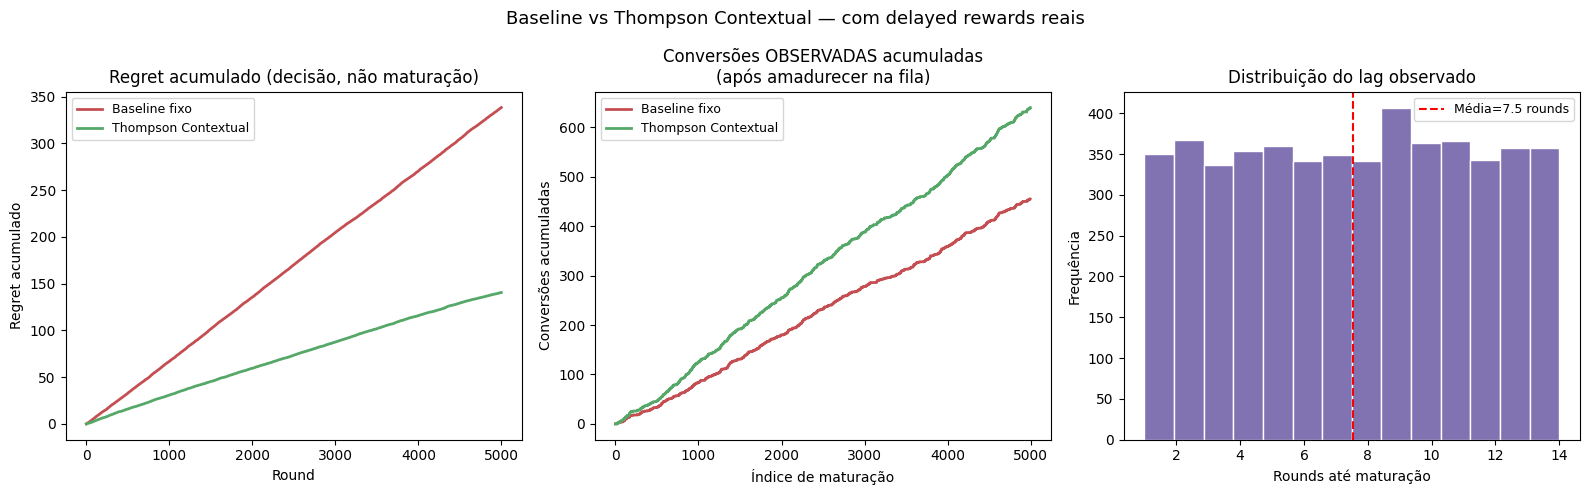

Salvo em reports/v2_comparacao_delay.png


In [8]:
cores_algo = {"Baseline fixo":"#C44E52", "Thompson Contextual":"#55A868"}

fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle("Baseline vs Thompson Contextual — com delayed rewards reais", fontsize=13)

# Regret acumulado
ax = axes[0]
for b in bandits:
    nome = b.nome
    ax.plot(resultados[nome]["regret_serie"], label=nome, color=cores_algo[nome], linewidth=2)
ax.set_title("Regret acumulado (decisão, não maturação)")
ax.set_xlabel("Round"); ax.set_ylabel("Regret acumulado")
ax.legend(fontsize=9)

# Conversões observadas acumuladas (ao longo da maturação, não da decisão)
ax = axes[1]
for b in bandits:
    nome = b.nome
    acum = np.cumsum(resultados[nome]["conversoes_observadas"])
    ax.plot(acum, label=nome, color=cores_algo[nome], linewidth=2)
ax.set_title("Conversões OBSERVADAS acumuladas\n(após amadurecer na fila)")
ax.set_xlabel("Índice de maturação"); ax.set_ylabel("Conversões acumuladas")
ax.legend(fontsize=9)

# Distribuição de lag observado
ax = axes[2]
lags_tc = [r["lag_rounds"] for r in resultados["Thompson Contextual"]["rewards"]]
ax.hist(lags_tc, bins=14, color="#8172B2", edgecolor="white")
ax.axvline(np.mean(lags_tc), color="red", linestyle="--", label=f"Média={np.mean(lags_tc):.1f} rounds")
ax.set_title("Distribuição do lag observado")
ax.set_xlabel("Rounds até maturação"); ax.set_ylabel("Frequência")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("reports/v2_comparacao_delay.png", dpi=130, bbox_inches="tight")
plt.show()
print("Salvo em reports/v2_comparacao_delay.png")

## Célula 9 — Salvar arquivos sintéticos finais

In [9]:
df_events  = pd.DataFrame(resultados["Thompson Contextual"]["events"])
df_rewards = pd.DataFrame(resultados["Thompson Contextual"]["rewards"])

df_events.to_parquet("data/synthetic_enrichment/offer_events.parquet", index=False)
df_rewards.to_parquet("data/synthetic_enrichment/delayed_rewards.parquet", index=False)

print(f"offer_events.parquet    → {len(df_events):,} linhas")
print(f"delayed_rewards.parquet → {len(df_rewards):,} linhas (apenas eventos já maturados)")
print(f"\nColunas de offer_events: {list(df_events.columns)}")
df_events.head()

offer_events.parquet    → 5,000 linhas
delayed_rewards.parquet → 4,993 linhas (apenas eventos já maturados)

Colunas de offer_events: ['event_id', 'round', 'ctx_segmento', 'ctx_age', 'ctx_job', 'arm_id', 'arm_name', 'canal', 'cta', 'p_conversao_real', 'timestamp_impression', 'policy_version']


,event_id,round,ctx_segmento,ctx_age,ctx_job,arm_id,arm_name,canal,cta,p_conversao_real,timestamp_impression,policy_version
0,EVT_Tho_0000000,0,technician__young,30,technician,ARM_CALL_CONSULTIVO,Ligação — abordagem consultiva,call,consultivo,0.1967,2024-01-01T00:00:00,v2.0-thompson-contextual-anchored
1,EVT_Tho_0000001,1,unemployed__mid,51,unemployed,ARM_SMS_SOFT,SMS — CTA suave,sms,soft,0.1276,2024-01-01T01:00:00,v2.0-thompson-contextual-anchored
2,EVT_Tho_0000002,2,blue-collar__young,26,blue-collar,ARM_SMS_SOFT,SMS — CTA suave,sms,soft,0.0893,2024-01-01T02:00:00,v2.0-thompson-contextual-anchored
3,EVT_Tho_0000003,3,blue-collar__mid,41,blue-collar,ARM_CALL_CONSULTIVO,Ligação — abordagem consultiva,call,consultivo,0.0952,2024-01-01T03:00:00,v2.0-thompson-contextual-anchored
4,EVT_Tho_0000004,4,admin.__young,29,admin.,ARM_SMS_URGENTE,SMS — CTA urgente,sms,urgente,0.2229,2024-01-01T04:00:00,v2.0-thompson-contextual-anchored


## Célula 10 — Documentos sintéticos de política comercial (RAG)

Conforme orientado: textos **fictícios** que simulam diretrizes da instituição.
Vão para `data/policies/` e serão indexados para o assistente LLM responder
"por que essa oferta foi escolhida" e checar suitability.

**Importante:** são todos sintéticos e devem ser declarados como tal — nunca
regras comerciais reais de um banco.

In [10]:
politicas = {
    "policy_suitability_geral.md": """# Política de Suitability — Term Deposit (SINTÉTICA)

> Documento fictício criado para fins de demonstração técnica do datathon.
> Não reflete política comercial real de nenhuma instituição.

## Regras de adequação (suitability)

1. Clientes com `default=yes` (crédito em situação de inadimplência) não devem
   receber abordagem via CALL consultivo — risco de mensagem inadequada sobre
   produto de investimento para perfil de risco elevado.

2. Clientes classificados como `age_senior` (>= 55 anos) E com `housing=no`
   E `loan=no` têm prioridade para abordagem CALL consultiva — perfil compatível
   com produto de longo prazo e maior disponibilidade para atendimento humano.

3. O braço SMS_URGENTE não deve ser usado mais de 2 vezes para o mesmo cliente
   em um intervalo de 30 dias — risco de percepção de pressão excessiva.

4. Clientes em segmento `student__young` não devem receber abordagem CALL —
   canal desproporcional ao perfil e ticket esperado do produto.
""",

    "policy_explicabilidade.md": """# Diretrizes de Explicabilidade de Decisão (SINTÉTICA)

> Documento fictício para orientar o assistente LLM na geração de explicações.

## Estrutura esperada de uma explicação de decisão

Toda decisão do bandit deve ser explicável em 3 partes:
1. **Segmento do cliente**: a que grupo o cliente pertence e sua taxa de conversão
   histórica observada na base.
2. **Braço escolhido**: qual canal/CTA foi selecionado e por quê (estimativa do bandit).
3. **Verificação de suitability**: confirmação de que a escolha não viola nenhuma
   regra do documento de suitability.

Se uma decisão violar suitability, o sistema deve reverter para o braço de
referência (ARM_EMAIL_SOFT) e registrar reason_code='suitability_override'.
""",

    "policy_canais.md": """# Política de Canais de Contato (SINTÉTICA)

> Documento fictício descrevendo características de cada canal simulado.

## Canais disponíveis

- **Email**: menor custo operacional, menor taxa de resposta imediata.
  Adequado para CTAs informativos.
- **SMS**: custo médio, alta taxa de abertura, mas risco de percepção invasiva
  se usado com frequência.
- **Call (ligação)**: maior custo operacional, requer disponibilidade humana,
  mas maior taxa de conversão para produtos de maior complexidade.

## Restrição de custo

O custo relativo de cada braço está documentado em offer_catalog.json no campo
`custo_rel`. Políticas de orçamento podem limitar o uso do braço CALL a um
percentual máximo do volume total de contatos.
""",
}

for nome_arquivo, conteudo in politicas.items():
    with open(f"data/policies/{nome_arquivo}", "w", encoding="utf-8") as f:
        f.write(conteudo)

print(f"✓ {len(politicas)} documentos de política salvos em data/policies/")
for nome in politicas:
    print(f"  data/policies/{nome}")

print()
print("Próximo passo (Etapa 5+): indexar esses arquivos em um vector store")
print("(ex.: chromadb, FAISS) para o assistente LLM fazer RAG sobre eles.")

✓ 3 documentos de política salvos em data/policies/
  data/policies/policy_suitability_geral.md
  data/policies/policy_explicabilidade.md
  data/policies/policy_canais.md

Próximo passo (Etapa 5+): indexar esses arquivos em um vector store
(ex.: chromadb, FAISS) para o assistente LLM fazer RAG sobre eles.


## Célula 11 — Golden set com casos de suitability

Atualizando o golden set para incluir explicitamente casos de
**"tentativa de furar suitability"**, conforme pedido.

In [11]:
def caso(case_id, category, description, ctx, expected, justification, criteria):
    return {
        "case_id": case_id, "category": category, "description": description,
        "context": ctx, "expected_action": expected,
        "justification": justification, "pass_criteria": criteria,
        "golden_set_version": "v2.0", "created_at": datetime.now().isoformat(),
    }

golden = [
    caso("GLD_001", "typical",
         "Segmento com alta conversão real → braço CALL deve ganhar espaço",
         {"segmento": "management__senior", "age":58,"job":"management"},
         "ARM_CALL_CONSULTIVO",
         "Multiplicador 1.45x sobre uma âncora já alta deve dominar após aprendizado.",
         "ARM_CALL_CONSULTIVO deve ser >= 35% das seleções após 300 rounds nesse segmento."),

    caso("GLD_002", "typical",
         "Segmento com baixa conversão real → braço de menor custo é aceitável",
         {"segmento": "student__young", "age":22,"job":"student"},
         "ARM_EMAIL_SOFT",
         "Conversão baixa não justifica canal caro (CALL); email é suficiente.",
         "ARM_CALL_CONSULTIVO não deve ultrapassar 10% das seleções para student__young."),

    # ── Suitability — casos centrais pedidos pelo coordenador ──
    caso("GLD_003", "suitability",
         "Cliente em default não deve receber CALL consultivo",
         {"default":"yes", "age":45, "job":"admin."},
         "NOT_ARM_CALL_CONSULTIVO",
         "Regra de suitability: default=yes proíbe abordagem CALL consultiva.",
         "Sistema deve aplicar reason_code='suitability_override' e reverter para ARM_EMAIL_SOFT."),

    caso("GLD_004", "suitability",
         "Tentativa de furar suitability via contexto manipulado",
         {"default":"yes", "_forcar_arm": "ARM_CALL_CONSULTIVO"},
         "REJECT_OR_OVERRIDE",
         "Mesmo se o payload tentar forçar um braço específico, a checagem de suitability deve prevalecer.",
         "API deve ignorar tentativa de override e aplicar a política de suitability, retornando reason_code='suitability_blocked'."),

    caso("GLD_005", "suitability",
         "Estudante jovem não deve receber CALL mesmo com alta estimativa do bandit",
         {"segmento": "student__young", "age":21,"job":"student"},
         "NOT_ARM_CALL_CONSULTIVO",
         "Regra de suitability bloqueia CALL para esse segmento independente da estimativa.",
         "ARM_CALL_CONSULTIVO deve ter frequência 0% para segmento student__young."),

    # ── Borda ──
    caso("GLD_006", "edge",
         "Cold-start: segmento nunca visto antes",
         {"segmento": "entrepreneur__senior", "age":61,"job":"entrepreneur"},
         "ANY",
         "Sem dados prévios no segmento; prior Beta(1,1) deve explorar uniformemente.",
         "Nenhum braço deve ultrapassar 40% nos primeiros 20 rounds desse segmento novo."),

    # ── Adversarial ──
    caso("GLD_007", "adversarial",
         "Reward fora do intervalo deve ser rejeitado",
         {"segmento": "admin.__mid", "reward_value_payload": 999},
         "REJECT",
         "Valores de reward fora de [0,1] indicam manipulação ou erro de integração.",
         "Sistema deve rejeitar e logar tentativa com reason_code='invalid_reward'."),

    caso("GLD_008", "adversarial",
         "Lag negativo ou maturação no passado deve ser rejeitado",
         {"lag_rounds_payload": -5},
         "REJECT",
         "Lag negativo violaria a causalidade da fila de delayed rewards.",
         "Sistema deve rejeitar evento com lag < 0."),

    # ── Fairness ──
    caso("GLD_009", "fairness",
         "Segmentos com poucos dados no Kaggle não devem ser ignorados",
         {"segmento": "housemaid__senior"},
         "ANY",
         "Shrinkage para y_global evita que segmentos raros fiquem com estimativa extrema.",
         "Segmento deve receber exposição mínima de 5% mesmo com poucos dados históricos."),

    caso("GLD_010", "fairness",
         "Custo operacional não deve excluir sistematicamente segmentos de baixa renda",
         {"segmento": "blue-collar__mid"},
         "ANY",
         "Mesmo que ARM_CALL custe mais, segmentos de menor renda não podem ser sempre excluídos dele.",
         "ARM_CALL_CONSULTIVO deve aparecer >= 5% das vezes mesmo em segmentos de menor renda."),
]

# Cobertura sistemática de jobs (segment_coverage)
for job_val in df["job"].unique():
    idx = len(golden) + 1
    golden.append(caso(
        f"GLD_{idx:03d}", "segment_coverage",
        f"Cobertura: job={job_val}",
        {"job": job_val},
        "ANY",
        f"Garantir exploração de todos os braços para job={job_val} respeitando suitability.",
        "Nenhum braço permitido com 0 seleções após 100 rounds para esse job."
    ))

with open("data/golden_set/evaluation_cases.jsonl", "w", encoding="utf-8") as f:
    for c in golden:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")

from collections import Counter
cats = Counter(c["category"] for c in golden)
print(f"✓ Golden set salvo: {len(golden)} casos")
for cat, n in cats.items():
    print(f"  {cat:<20} {n} casos")

✓ Golden set salvo: 22 casos
  typical              2 casos
  suitability          3 casos
  edge                 1 casos
  adversarial          2 casos
  fairness             2 casos
  segment_coverage     12 casos


## Célula 12 — Relatório de geração (atualizado)

In [12]:
report = f"""# Relatório de geração de dados sintéticos — v2

Gerado em: {datetime.now().isoformat()}
Seed: {SEED}

## Mudanças em relação à v1 (alinhamento com orientação do coordenador)

1. **Braços redefinidos**: variações de canal/CTA do produto único do Kaggle
   (term deposit), não mais produtos financeiros inventados.
2. **Calibração por âncora**: a probabilidade de conversão de cada braço é
   `y_real_do_segmento × multiplicador_do_braço`. O braço de referência
   (ARM_EMAIL_SOFT) é o mais próximo do dado observado.
3. **Fila real de delayed rewards**: implementada com heap, eventos amadurecem
   em rounds futuros reais dentro do loop de simulação — não é mais um sorteio
   instantâneo de status.
4. **Documentos de política (RAG)**: criados em data/policies/, sintéticos e
   declarados como tal.
5. **Golden set**: expandido com categoria 'suitability' cobrindo tentativas
   de furar regras de adequação.

## Parâmetros
- Eventos simulados: {N_EVENTOS:,}
- Braços: {len(ARMS)}
- Lag máximo: {MAX_LAG} rounds
- Segmentos distintos no Kaggle: {len(Y_POR_SEGMENTO)}
- Shrinkage aplicado para segmentos com < {MIN_AMOSTRAS} amostras

## Declaração de honestidade (conforme orientação)

A recompensa é sintética e calibrada a partir do `y` real do Bank Marketing,
mas o multiplicador de cada braço (canal/CTA) é uma hipótese de domínio, não
um resultado de produção. Os números de conversão e regret apresentados neste
projeto **não representam uplift real de negócio** — são evidência de que o
mecanismo de aprendizado adaptativo funciona corretamente dentro do simulador
construído, com calibração defensável e rastreável ao dado original.

## Limitações
- O multiplicador de cada braço é fixo — não captura interação canal × segmento.
- Shrinkage para segmentos pequenos usa peso linear simples, não um modelo bayesiano completo.
- A fila de delayed rewards assume lag uniforme entre 1 e {MAX_LAG} rounds.
"""

with open("reports/data-generation.md", "w", encoding="utf-8") as f:
    f.write(report)

print("✓ reports/data-generation.md atualizado")
print()
print("ARQUIVOS FINAIS GERADOS:")
for p in ["data/synthetic_enrichment/offer_catalog.json",
          "data/synthetic_enrichment/offer_events.parquet",
          "data/synthetic_enrichment/delayed_rewards.parquet",
          "data/golden_set/evaluation_cases.jsonl",
          "data/policies/policy_suitability_geral.md",
          "data/policies/policy_explicabilidade.md",
          "data/policies/policy_canais.md",
          "reports/data-generation.md",
          "reports/v2_comparacao_delay.png"]:
    exists = "✓" if Path(p).exists() else "✗"
    print(f"  {exists} {p}")

✓ reports/data-generation.md atualizado

ARQUIVOS FINAIS GERADOS:
  ✓ data/synthetic_enrichment/offer_catalog.json
  ✓ data/synthetic_enrichment/offer_events.parquet
  ✓ data/synthetic_enrichment/delayed_rewards.parquet
  ✓ data/golden_set/evaluation_cases.jsonl
  ✓ data/policies/policy_suitability_geral.md
  ✓ data/policies/policy_explicabilidade.md
  ✓ data/policies/policy_canais.md
  ✓ reports/data-generation.md
  ✓ reports/v2_comparacao_delay.png
